In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgauss

## Bayesian Lasso – Gibbs Sampler

We want to sample from the posterior

$$
\rho(x) \propto \exp\!\left(-\beta (\lambda \|x\|_1 + \frac{1}{2}\|Ax - y\|^2\right))
$$


where  
- $ A \in \mathbb{R}^{m \times d} $ 
- $ y \in \mathbb{R}^m $ 
- $ \beta > 0, \lambda > 0 $

---

Using the identity $
e^{-a|z|}=
\frac{a}{\sqrt{2\pi}}
\int_0^\infty
\eta^{-1/2}
\exp\!\left(
-\frac{z^2}{2\eta}
-\frac{a^2 \eta}{2}
\right)
\, d\eta$ We introduce latent variables $\eta_i > 0$ and obtain the density

$$ 
\tilde{\pi}(x,\eta)
\propto
\prod_{i=1}^d \eta_i^{-1/2}
\exp\!\left(
-\sum_{i=1}^d
\left(
\frac{x_i^2}{2\eta_i}
+
\frac{\beta^2 \lambda^2 \eta_i}{2}
\right)
-
\frac{\beta}{2}\|Ax-y\|^2
\right)
$$

---

### Gibbs Update 1 : Sample $ x \mid \eta$

$$
x \mid \eta \sim \mathcal{N}(\mu, \Sigma)
$$

where
- $ C_\eta = \mathrm{diag}(1/\eta) + \beta A^\top A $
- $\Sigma = C_\eta^{-1}$
- $\mu = \beta \Sigma A^\top y$


### Gibbs Update 1 : Sample $\eta_i \mid x_i$

Let $z_i = 1/\eta_i$. Then

$$
z_i \mid x_i
\sim
\text{Inverse-Gaussian}
\left(
\mu_i = \frac{\beta \lambda}{|x_i|},
\;
\lambda_i = (\beta \lambda)^2
\right)
$$

---

### Algorithm

Repeat:

1. Sample $x \mid \eta$ (Gaussian step)
2. Sample each $ \eta_i \mid x_i$ (Inverse-Gaussian step)

After burn-in, the samples $x^{(t)}$ approximate the posterior $\rho(x)$

In [12]:
def gibbs_lasso_1d(A, b, Beta, Lambda, n_samples, burn_in):
    
    np.random.seed(0)
    tol = 1e-10
    
    m, d = A.shape 
    
    samples = []
    
    x = np.zeros(d)
    eta = np.ones(d)

    AT_A = A.T @ A
    AT_b = A.T @ b
    
    for t in range(n_samples):
        
        C = np.diag(1.0 / eta) + Beta * AT_A 
        sigma = np.linalg.inv(C)
        mu = Beta * (sigma @ AT_b)
        
        x = np.random.multivariate_normal(mu, sigma)
        
        for i in range(d):
            nu_ig = Beta * Lambda / (np.abs(x[i]) + tol)
            lam_ig = (Beta * Lambda)**2
            
            z = invgauss.rvs(mu=nu_ig/lam_ig, scale=lam_ig)
            eta[i] = 1.0 / z
        
        if t >= burn_in:
            samples.append(x.copy())
    
    return np.array(samples)

In [ ]:
# A = np.array([[1.0]])
# b = np.array([2.0])

A = np.array([[1.0],    
              [1.5]])   
b = np.array([2.0,2.6])  

gibbs_samples = gibbs_lasso_1d(A=A, b=b, Beta=1.0, Lambda=2.0, n_samples=150000, burn_in=3000)

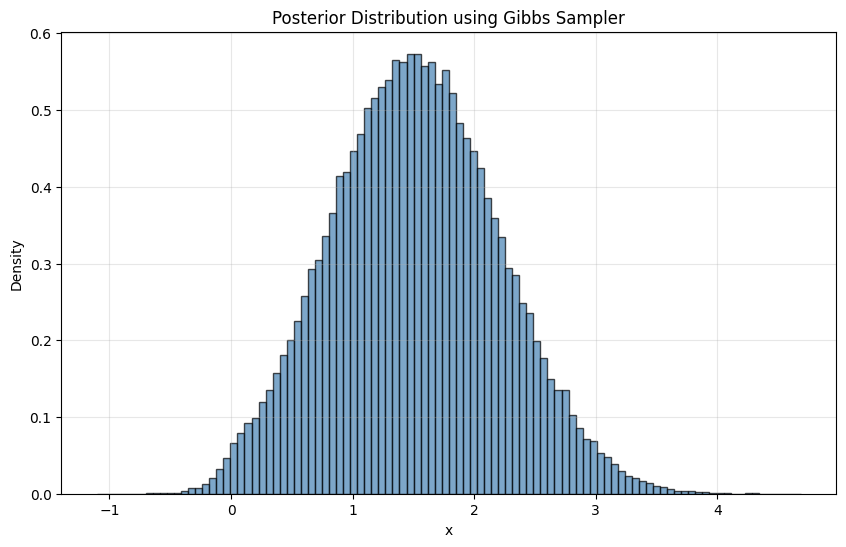

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(gibbs_samples.flatten(), bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Posterior Distribution using Gibbs Sampler')
plt.grid(True, alpha=0.3)
plt.show()